# FSDD 说话人泛化实验：从“会背题”到“会识别新的人”

前一个 Capstone 已证明 WAV、流式 Log-Mel、因果模型、CTC、解码和服务能连起来，但训练风格样本 10/10、未见说话人却很差。现在解决真正的机器学习问题：**模型对没有参与训练的人能否泛化？**

本实验使用固定版本的完整 Free Spoken Digit Dataset：6 位说话人、3,000 条 8 kHz 英语数字录音，每人每数字 50 条。我们会：

1. 校验 archive SHA256、文件数、文件名、采样率和许可；
2. 按 speaker 而不是 recording index 划分 train/dev/test；
3. 用同一说话人的 1～4 个真人片段构造多 token utterance；
4. 训练 clean baseline 与 gain/noise augmentation 两个预先定义的实验；
5. 只用 dev 选 epoch，固定后才查看 test；
6. 分析 CER、exact、长度分桶、插删替错误和流式一致性。

上游许可：CC BY-SA 4.0。下载的 3,000 个 WAV 只保存在 `.local_data/`，不会提交到本仓库。

## 完成标准

- 能解释数据版本、archive hash、manifest 各解决什么问题；
- 能证明 train/dev/test 的 speaker 集合两两无交集；
- 能区别“官方 recording-index split”和“speaker-disjoint split”；
- 能写出 CTC 变长 batch 的四个核心张量及 shape；
- 能解释为什么单 token CTC 不等于序列 ASR；
- 能正确使用 train、dev、test，不在看到 test 后继续调同一实验；
- 能读训练曲线、CER、exact、长度分桶和错误样例；
- 能证明 checkpoint 跨 chunk 数值/文本一致；
- 72 分综合测试至少达到 58 分。

In [1]:
from pathlib import Path
from collections import Counter, defaultdict
import json
import math
import sys
import time

import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib import font_manager
import librosa.display
import ipywidgets as widgets
from IPython.display import Audio, display

installed_fonts = {f.name for f in font_manager.fontManager.ttflist}
for font_name in ["Microsoft YaHei", "Noto Sans CJK SC", "SimHei", "Arial Unicode MS"]:
    if font_name in installed_fonts:
        plt.rcParams["font.sans-serif"] = [font_name]
        break
plt.rcParams["axes.unicode_minus"] = False

candidates = [Path.cwd(), Path.cwd().parent]
ROOT = next(path for path in candidates if (path / "pyproject.toml").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from acoustic_engine.features import LogMelFrontend, StreamingLogMelFrontend
from acoustic_engine.streaming import StreamingAcousticEngine
from fsdd_generalization.data import (
    ARCHIVE_SHA256, FSDD_REVISION, SplitSpec, prepare_fsdd
)
from fsdd_generalization.training import (
    augment_waveform, build_sequence_specs, frontend_config,
    load_waveform, sequence_waveform
)

recordings_dir, splits = prepare_fsdd(ROOT / ".local_data", validate_audio=False)
manifest = json.loads((ROOT / "artifacts" / "fsdd_speaker_disjoint_manifest.json").read_text(encoding="utf-8"))
results = json.loads((ROOT / "artifacts" / "fsdd_speaker_disjoint_results.json").read_text(encoding="utf-8"))
checkpoint = ROOT / "artifacts" / "fsdd_speaker_disjoint_ctc.pt"
print("recordings:", recordings_dir)
print("revision:", FSDD_REVISION)
print("archive SHA256:", ARCHIVE_SHA256)
print("checkpoint:", checkpoint, checkpoint.stat().st_size, "bytes")

recordings: <REPO_ROOT>\.local_data\fsdd-26eb9aaf\recordings
revision: 26eb9aaf76e81b692f806f9140c2d2777410d7a1
archive SHA256: beaca4fb849cad13103b2cffba913b3d7fdb5f15222da4ddd07187b3c38a757a
checkpoint: <REPO_ROOT>\artifacts\fsdd_speaker_disjoint_ctc.pt 517807 bytes


## 1. 可复现数据不是“我下载过一个 ZIP”

需要同时记录：

- **上游 revision**：指定数据仓库的历史状态；
- **archive SHA256**：确认本地收到的字节完全相同；
- **manifest**：记录每个文件的 digit、speaker、index 和 split；
- **音频契约**：3,000 个文件均为 mono、8 kHz、非空；
- **许可与署名**：数据可用不等于可以丢掉上游许可。

FSDD 会随贡献增长；只写“最新版”会让未来的人无法重现实验。固定 revision 不是形式主义，而是科学实验的输入版本控制。

In [2]:
print("manifest counts:", manifest["counts"])
print("split spec:", manifest["split_spec"])
print("manifest entries:", len(manifest["entries"]))
assert manifest["revision"] == FSDD_REVISION
assert manifest["archive_sha256"] == ARCHIVE_SHA256
assert manifest["counts"] == {"train":2000, "dev":500, "test":500}
assert len(manifest["entries"]) == 3000

entries_by_split = {
    name: [row for row in manifest["entries"] if row["split"] == name]
    for name in ["train", "dev", "test"]
}
speaker_sets = {
    name: {row["speaker"] for row in rows}
    for name, rows in entries_by_split.items()
}
print("speakers:", speaker_sets)
assert not (speaker_sets["train"] & speaker_sets["dev"])
assert not (speaker_sets["train"] & speaker_sets["test"])
assert not (speaker_sets["dev"] & speaker_sets["test"])

manifest counts: {'train': 2000, 'dev': 500, 'test': 500}
split spec: {'train_speakers': ['george', 'jackson', 'lucas', 'nicolas'], 'dev_speakers': ['theo'], 'test_speakers': ['yweweler']}
manifest entries: 3000
speakers: {'train': {'george', 'lucas', 'jackson', 'nicolas'}, 'dev': {'theo'}, 'test': {'yweweler'}}


### 为什么官方 index split 不是本实验要的 split？

上游 README 建议 index 0～4 做 test、5～49 做 train。它适合“同一批说话人的新录音”问题，但 6 位说话人都会同时出现在 train 和 test。我们要回答的是“全新说话人”，所以 speaker 必须互斥。

两种 split 都可以合法使用，但回答的问题不同。最危险的不是选择某一种，而是用 recording split 的高分冒充 speaker-independent 能力。

官方 index split 中 train/test 共同说话人: ['george', 'jackson', 'lucas', 'nicolas', 'theo', 'yweweler']
本实验 speaker split 中共同说话人: set() set()


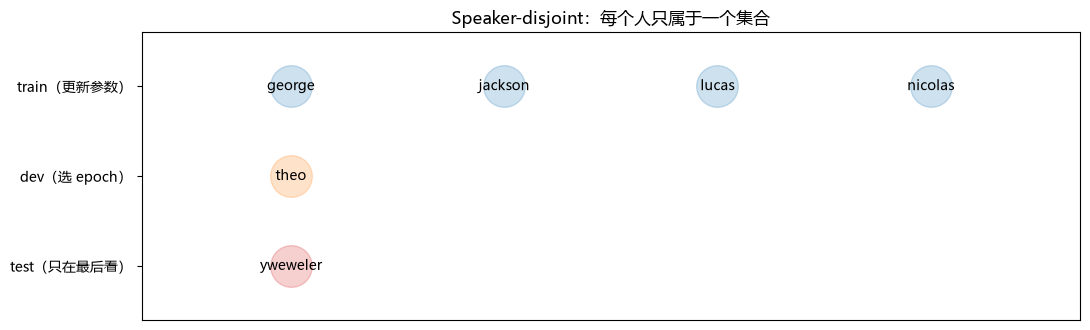

In [3]:
official_train = [row for row in manifest["entries"] if row["index"] >= 5]
official_test = [row for row in manifest["entries"] if row["index"] < 5]
official_overlap = (
    {row["speaker"] for row in official_train}
    & {row["speaker"] for row in official_test}
)
print("官方 index split 中 train/test 共同说话人:", sorted(official_overlap))
print("本实验 speaker split 中共同说话人:",
      speaker_sets["train"] & speaker_sets["dev"],
      speaker_sets["train"] & speaker_sets["test"])
assert official_overlap == set(manifest["split_spec"]["train_speakers"] + manifest["split_spec"]["dev_speakers"] + manifest["split_spec"]["test_speakers"])

fig, ax = plt.subplots(figsize=(11, 3.4))
y = {"train":2, "dev":1, "test":0}
colors = {"train":"C0", "dev":"C1", "test":"C3"}
for split_name, speakers in speaker_sets.items():
    for index, speaker in enumerate(sorted(speakers)):
        ax.scatter(index, y[split_name], s=900, color=colors[split_name], alpha=.22)
        ax.text(index, y[split_name], speaker, ha="center", va="center")
ax.set_yticks([0,1,2], ["test（只在最后看）", "dev（选 epoch）", "train（更新参数）"])
ax.set_xticks([]); ax.set_xlim(-.7, 3.7); ax.set_ylim(-.6, 2.6)
ax.set_title("Speaker-disjoint：每个人只属于一个集合")
plt.tight_layout(); plt.show()

### 数据划分检查题（每题 2 分）

1. CMVN mean/std 应在哪个集合计算？为什么？
2. 训练到第 8 和第 10 epoch，应该看 dev 还是 test 选择？
3. 看完 test 后发现增强很差，能否调整增强并继续把同一个 test 称为盲测？
4. 文件名不同是否足以证明没有说话人泄漏？

<details><summary>参考答案</summary>

只用 train 统计；epoch 只用 dev；看过 test 再据此调参会使它变成开发数据，需要新盲测或诚实标注探索性结果；文件不同仍可能来自同一说话人/同一会话，必须按实体 ID 审计。

</details>

## 2. 先听数据：标签表不是声音本身

每位说话人的口音、基频、语速和录音条件不同。下面播放每人的一条数字 7。模型不能记住“Jackson 的 7 长什么样”，而要学习跨人的稳定声学结构。

george    split=train samples= 5131 duration=0.641s


jackson   split=train samples= 3457 duration=0.432s


lucas     split=train samples= 5299 duration=0.662s


nicolas   split=train samples= 2979 duration=0.372s


theo      split=dev   samples= 3428 duration=0.428s


yweweler  split=test  samples= 3491 duration=0.436s


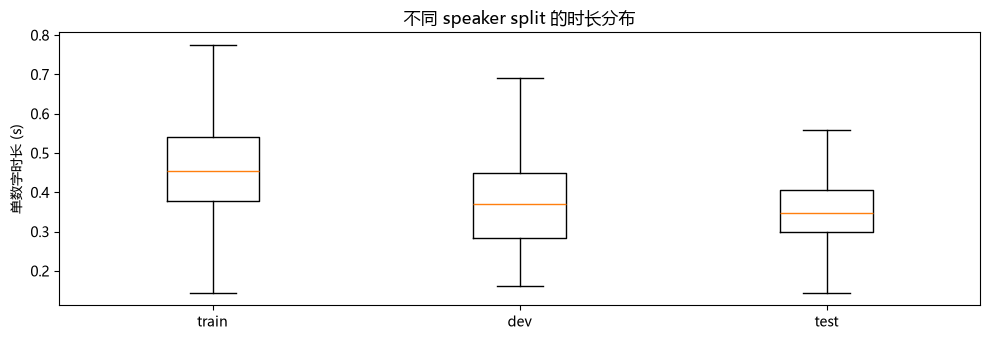

In [4]:
speaker_examples = {}
for split_name, rows in splits.items():
    for recording in rows:
        if recording.digit == "7" and recording.index == 0:
            speaker_examples[recording.speaker] = (split_name, recording)
for speaker in sorted(speaker_examples):
    split_name, recording = speaker_examples[speaker]
    waveform = load_waveform(recording)
    print(f"{speaker:9s} split={split_name:5s} samples={len(waveform):5d} duration={len(waveform)/8000:.3f}s")
    display(Audio(waveform.numpy(), rate=8000))

durations = defaultdict(list)
for split_name, rows in splits.items():
    durations[split_name] = [len(load_waveform(row))/8000 for row in rows]
plt.figure(figsize=(10, 3.5))
plt.boxplot([durations[name] for name in ["train","dev","test"]], tick_labels=["train","dev","test"], showfliers=False)
plt.ylabel("单数字时长 (s)"); plt.title("不同 speaker split 的时长分布")
plt.tight_layout(); plt.show()

## 3. 为什么要构造 1～4 token utterance？

第一版完整数据实验把每条录音当成一个数字。虽然损失函数叫 CTCLoss，但 target 永远只有一个 token；把 `4,6,3` 三条测试录音拼接后，模型仍常只输出一个数字。这是**单数字分类式训练**，不是完整序列 ASR。

正式实验从同一 speaker 的真实片段构造 1～4 位数字串，中间插入 40～100 ms 静音；每 10 条至少一条含相邻重复数字，让 CTC 必须学会 blank 分隔。拼接波形是课程派生数据，原始片段仍来自 FSDD。

In [5]:
train_config = results["augmented"]["config"]
train_specs = build_sequence_specs(
    splits["train"], count=30,
    min_digits=train_config["min_digits"], max_digits=train_config["max_digits"],
    seed=train_config["seed"]+101, prefix="demo"
)
lengths = Counter(len(spec.text) for spec in train_specs)
repeats = [spec for spec in train_specs if any(a == b for a,b in zip(spec.text, spec.text[1:]))]
print("前 30 条长度分布:", lengths)
print("含相邻重复的例子:", [(spec.text, spec.speaker) for spec in repeats[:5]])

example_spec = repeats[0]
example_waveform = sequence_waveform(example_spec)
print("示例 target:", example_spec.text, "speaker:", example_spec.speaker,
      "duration:", len(example_waveform)/8000)
display(Audio(example_waveform.numpy(), rate=8000))

前 30 条长度分布: Counter({3: 9, 2: 8, 4: 7, 1: 6})
含相邻重复的例子: [('44', 'george'), ('11', 'lucas'), ('889', 'george'), ('4001', 'jackson'), ('004', 'nicolas')]
示例 target: 44 speaker: george duration: 0.968625


### 变长 CTC batch 的四个关键量

- padded features：`[B, T_max, F]`；
- input lengths：`[B]`，告诉模型每条真实帧数；
- flattened targets：`[sum(U_i)]`，把每条 token 串首尾拼平；
- target lengths：`[B]`，告诉 CTC 怎样切回每条目标。

把 padding 帧误算进 input length，会污染 loss；target length 大于可对齐时间时，CTC 无有效路径。`zero_infinity=True` 能防止数值炸掉，却不应被用来隐藏系统性长度错误。

## 4. 数据增强：增加训练分布，不是给标签施魔法

本实验的预注册对照：

- baseline：每条训练序列只保留 clean 版本；
- augmented：额外生成一条随机 gain（-8～+8 dB）与白噪声（5～25 dB SNR）副本；
- dev/test：始终 clean，不做随机增强；
- 随机种子固定，两个实验可复现。

增强只使用 train 波形，不会把 dev/test 音频混进来。增强也不保证有效：若目标差异主要来自口音或房间，白噪声可能不是正确归纳偏置。

In [6]:
clean_demo = example_waveform

def show_augmentation(seed=17):
    augmented = augment_waveform(clean_demo, seed)
    cfg = frontend_config()
    front = LogMelFrontend(cfg)
    clean_feature = front(clean_demo)
    aug_feature = front(augmented)
    fig, ax = plt.subplots(2, 2, figsize=(13, 6))
    seconds = np.arange(len(clean_demo))/8000
    ax[0,0].plot(seconds, clean_demo.numpy(), lw=.5); ax[0,0].set(title="clean 波形", ylabel="幅值")
    ax[1,0].plot(seconds, augmented.numpy(), lw=.5); ax[1,0].set(title="gain + noise", xlabel="时间 (s)", ylabel="幅值")
    ax[0,1].imshow(clean_feature.T.numpy(), origin="lower", aspect="auto"); ax[0,1].set(title="clean Log-Mel", ylabel="Mel bin")
    ax[1,1].imshow(aug_feature.T.numpy(), origin="lower", aspect="auto"); ax[1,1].set(title="augmented Log-Mel", xlabel="frame", ylabel="Mel bin")
    plt.tight_layout(); plt.show()
    print("clean RMS:", float(clean_demo.square().mean().sqrt()),
          "augmented RMS:", float(augmented.square().mean().sqrt()))

augmentation_ui = widgets.interactive(
    show_augmentation,
    seed=widgets.IntSlider(min=0, max=100, value=17, description="随机种子", continuous_update=False)
)
display(augmentation_ui)

interactive(children=(IntSlider(value=17, continuous_update=False, description='随机种子'), Output()), _dom_classe…

## 5. 训练曲线：训练 loss 下降不等于新说话人变好

每个实验都只根据 theo 的 dev CER 保存最佳 epoch，并在连续 7 个 epoch 无提升时 early stop。yweweler test 标签在模型选择完成后才计算。

观察两个典型现象：

- train loss 很快接近 0，说明模型能记住四位训练说话人；
- dev CER 在中途达到最低后反弹，说明继续拟合 train 反而损害新说话人。

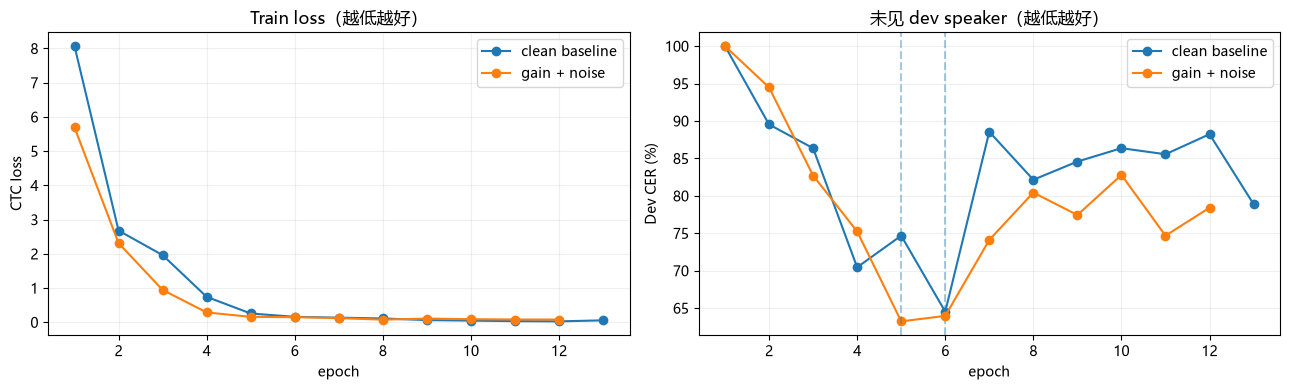

best epochs: {'baseline': 6, 'augmented': 5}


In [7]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for name, label in [("baseline","clean baseline"), ("augmented","gain + noise")]:
    history = results[name]["history"]
    epochs = [row["epoch"] for row in history]
    ax[0].plot(epochs, [row["train_loss"] for row in history], "o-", label=label)
    ax[1].plot(epochs, [100*row["dev_cer"] for row in history], "o-", label=label)
    best = results[name]["best_epoch"]
    ax[1].axvline(best, ls="--", alpha=.4)
ax[0].set(xlabel="epoch", ylabel="CTC loss", title="Train loss（越低越好）")
ax[1].set(xlabel="epoch", ylabel="Dev CER (%)", title="未见 dev speaker（越低越好）")
for axis in ax: axis.grid(alpha=.2); axis.legend()
plt.tight_layout(); plt.show()
print("best epochs:", {name: results[name]["best_epoch"] for name in ["baseline","augmented"]})

### 训练曲线检查题（每题 2 分）

1. train loss 继续下降、dev CER 上升，叫什么？应保存哪一个 epoch？
2. 为什么 early stopping 的 patience 也算超参数？
3. 两个实验随机 seed 不同，会引入什么混淆？
4. 能否选择 test CER 最低的 epoch 再报告它？

<details><summary>参考答案</summary>

过拟合，应保存 dev 最佳；patience 改变训练停止点；seed 差异可能被误认为增强效果，因此对照应共享 seed 或多 seed 报告；不能，test 不能参与 epoch 选择。

</details>

## 6. 冻结测试结果：改善了，但没有“解决”

CER 定义为 `(substitution + deletion + insertion) / reference characters`；exact match 要求整串完全相同，所以会随长度迅速变难。

baseline 与 augmented 是运行前定义好的 A/B；两者各自在 dev 上选好 checkpoint 后才计算同一个冻结 test。看到结果后，本 Notebook 不再用该 test 调第三个版本。

baseline best=6 dev CER=64.53% test CER=56.55% test seq exact=16.00% test single exact=39.80%
augmented best=5 dev CER=63.23% test CER=40.16% test seq exact=32.40% test single exact=56.60%


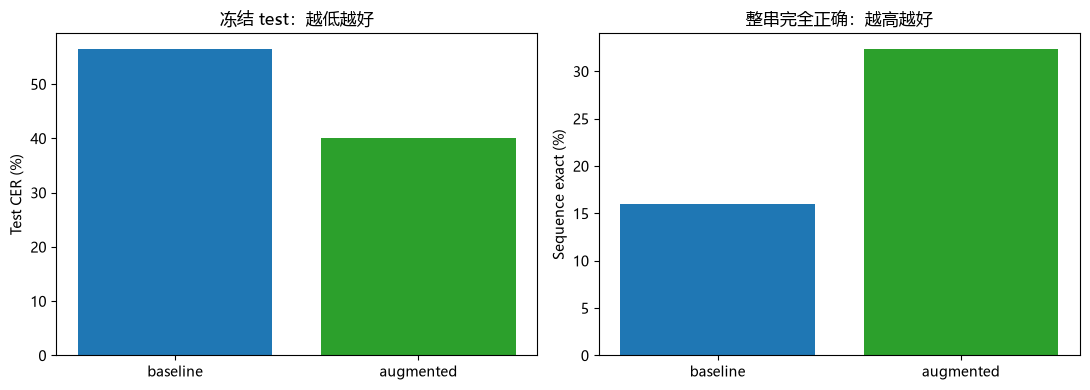

In [8]:
summary_rows = []
for name in ["baseline", "augmented"]:
    experiment = results[name]
    summary_rows.append({
        "name": name,
        "best_epoch": experiment["best_epoch"],
        "dev_CER": experiment["dev"]["cer"],
        "dev_exact": experiment["dev"]["exact_rate"],
        "test_CER": experiment["test"]["cer"],
        "test_exact": experiment["test"]["exact_rate"],
        "test_single_exact": experiment["test_single_digit"]["exact_rate"],
    })
for row in summary_rows:
    print(row["name"],
          f"best={row['best_epoch']}",
          f"dev CER={row['dev_CER']:.2%}",
          f"test CER={row['test_CER']:.2%}",
          f"test seq exact={row['test_exact']:.2%}",
          f"test single exact={row['test_single_exact']:.2%}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
x = np.arange(2)
ax[0].bar(x, [100*r["test_CER"] for r in summary_rows], color=["C0","C2"])
ax[0].set_xticks(x, ["baseline","augmented"]); ax[0].set(ylabel="Test CER (%)", title="冻结 test：越低越好")
ax[1].bar(x, [100*r["test_exact"] for r in summary_rows], color=["C0","C2"])
ax[1].set_xticks(x, ["baseline","augmented"]); ax[1].set(ylabel="Sequence exact (%)", title="整串完全正确：越高越好")
plt.tight_layout(); plt.show()
assert results["augmented"]["test"]["cer"] < results["baseline"]["test"]["cer"]

这次增强把 test CER 从约 56.5% 降到 40.2%，sequence exact 从 16.0% 提升到 32.4%。这是实质改善，但仍有约四成字符错误，绝不能写成“说话人无关识别已完成”。

更微妙的是：dev 上两者非常接近，test 上差距却较大。只有一个 dev speaker 和一个 test speaker，单个人的口音/录音条件会主导结果。下一轮应做 leave-one-speaker-out 或收集更多 speaker，而不是根据 yweweler 结果继续手调并重复声称盲测。

## 7. 长度分桶：总体指标会隐藏问题结构

一位数字只需一个 token 正确；四位字符串任一位错，exact 就失败。CER 对长度更可比，但也要看 insertion/deletion 是否随长句累积。

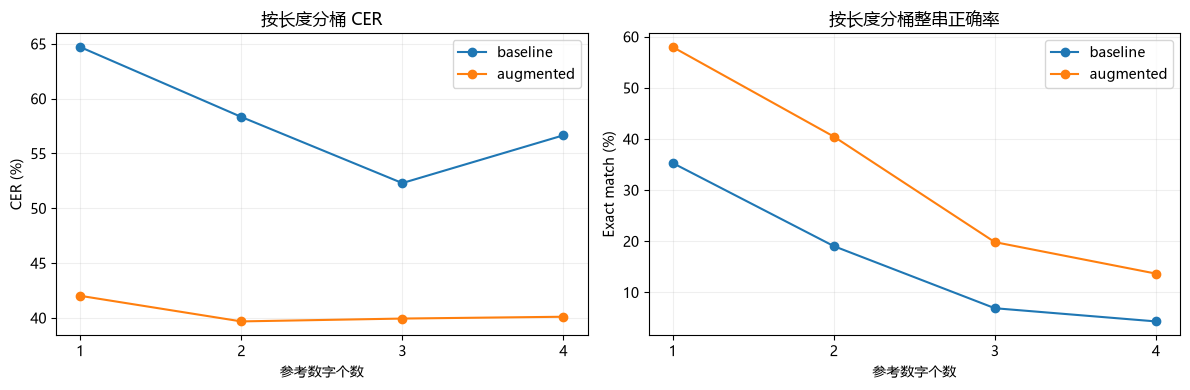

augmented per length: {'1': {'exact': 69, 'total': 119, 'exact_rate': 0.5798319327731093, 'cer': 0.42016806722689076}, '2': {'exact': 51, 'total': 126, 'exact_rate': 0.40476190476190477, 'cer': 0.3968253968253968}, '3': {'exact': 23, 'total': 116, 'exact_rate': 0.19827586206896552, 'cer': 0.3994252873563218}, '4': {'exact': 19, 'total': 139, 'exact_rate': 0.1366906474820144, 'cer': 0.4010791366906475}}


In [9]:
baseline_length = results["baseline"]["test"]["per_length"]
augmented_length = results["augmented"]["test"]["per_length"]
lengths = sorted(map(int, augmented_length))
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for data, label in [(baseline_length,"baseline"), (augmented_length,"augmented")]:
    ax[0].plot(lengths, [100*data[str(n)]["cer"] for n in lengths], "o-", label=label)
    ax[1].plot(lengths, [100*data[str(n)]["exact_rate"] for n in lengths], "o-", label=label)
ax[0].set(xlabel="参考数字个数", ylabel="CER (%)", title="按长度分桶 CER")
ax[1].set(xlabel="参考数字个数", ylabel="Exact match (%)", title="按长度分桶整串正确率")
for axis in ax: axis.set_xticks(lengths); axis.grid(alpha=.2); axis.legend()
plt.tight_layout(); plt.show()
print("augmented per length:", augmented_length)

## 8. 错误不是一个 CER 数字：看插入、删除、替换和声音

下方回溯编辑路径，把错误拆成 substitution、deletion、insertion。然后播放一条完全正确和一条错误的冻结 test utterance。听音不是为了主观挑模型，而是提出下一轮可检验假设：是相似数字、静音边界、说话人音色，还是重复 token？

编辑操作: Counter({'correct': 771, 'substitution': 407, 'deletion': 97, 'insertion': 8})


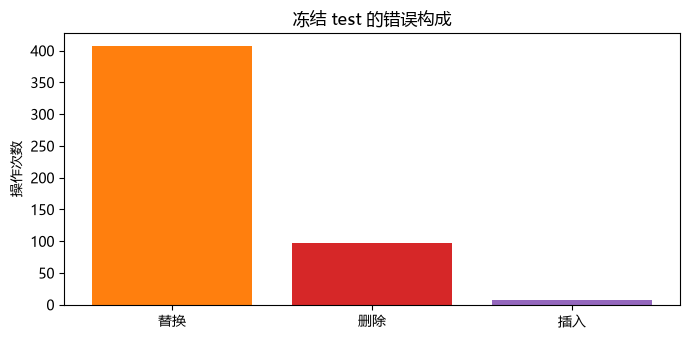

reference= 857 hypothesis= 857 correct= True duration= 1.03


reference= 8817 hypothesis= 8855 correct= False duration= 1.508


In [10]:
def edit_ops(reference, hypothesis):
    rows, cols = len(reference)+1, len(hypothesis)+1
    dp = np.zeros((rows, cols), dtype=int)
    dp[:,0] = np.arange(rows); dp[0,:] = np.arange(cols)
    for i in range(1, rows):
        for j in range(1, cols):
            dp[i,j] = min(dp[i-1,j]+1, dp[i,j-1]+1,
                          dp[i-1,j-1]+(reference[i-1] != hypothesis[j-1]))
    i,j = len(reference),len(hypothesis); ops=[]
    while i or j:
        if i and j and dp[i,j] == dp[i-1,j-1] + (reference[i-1] != hypothesis[j-1]):
            ops.append("correct" if reference[i-1] == hypothesis[j-1] else "substitution"); i-=1; j-=1
        elif i and dp[i,j] == dp[i-1,j]+1:
            ops.append("deletion"); i-=1
        else:
            ops.append("insertion"); j-=1
    return list(reversed(ops))

predictions = results["augmented"]["test"]["predictions"]
operation_counts = Counter(
    op for row in predictions for op in edit_ops(row["reference"], row["hypothesis"])
)
print("编辑操作:", operation_counts)
error_counts = [operation_counts[name] for name in ["substitution","deletion","insertion"]]
plt.figure(figsize=(7,3.5)); plt.bar(["替换","删除","插入"], error_counts, color=["C1","C3","C4"])
plt.ylabel("操作次数"); plt.title("冻结 test 的错误构成"); plt.tight_layout(); plt.show()

test_specs = build_sequence_specs(
    splits["test"], train_config["test_sequences"], train_config["min_digits"],
    train_config["max_digits"], train_config["seed"]+303, "test"
)
spec_lookup = {spec.name: spec for spec in test_specs}
chosen_rows = [next(row for row in predictions if row["correct"]),
               next(row for row in predictions if not row["correct"])]
for row in chosen_rows:
    spec = spec_lookup[row["utterance"]]
    wav = sequence_waveform(spec)
    print("reference=", row["reference"], "hypothesis=", row["hypothesis"],
          "correct=", row["correct"], "duration=", round(len(wav)/8000,3))
    display(Audio(wav.numpy(), rate=8000))

### 错误分析纪律

不要听了 3 条就宣布结论。正确流程是：

1. 从整体指标发现异常分桶；
2. 随机抽取该分桶的若干错误和正确对照；
3. 提出假设，例如“相邻重复导致 deletion”；
4. 写能覆盖整个分桶的统计或实验；
5. 在 dev 验证改动，保留新的真正盲测。

## 9. 加载冻结 checkpoint，证明它仍是真正的流式模型

训练质量和流式正确性是两条独立轴。即使 CER 很高，也必须保证 chunk 不会改变算法；即使 chunk 完全等价，也不能因此声称模型准确。

In [11]:
engine = StreamingAcousticEngine.load(checkpoint)
correct_row = chosen_rows[0]
correct_spec = spec_lookup[correct_row["utterance"]]
heldout_waveform = sequence_waveform(correct_spec)

whole_frontend = LogMelFrontend(engine.frontend_config)
whole_features = whole_frontend(heldout_waveform)
rng = np.random.default_rng(77)
streamed_frontend = StreamingLogMelFrontend(engine.frontend_config)
pieces=[]; cursor=0
while cursor < len(heldout_waveform):
    end=min(len(heldout_waveform), cursor+int(rng.integers(1,1001)))
    pieces.append(streamed_frontend.accept(heldout_waveform[cursor:end], final=end==len(heldout_waveform)))
    cursor=end
streamed_features=torch.cat(pieces)
feature_error=float((whole_features-streamed_features).abs().max())

normalized=(whole_features-engine.feature_mean)/engine.feature_std
with torch.inference_mode():
    whole_logits,_=engine.model(normalized[None],torch.tensor([len(normalized)]))
    model_pieces=[]; state=None
    boundaries=[1,7,19,20,len(normalized)]; start=0
    for end in boundaries:
        if end<=start: continue
        out,state=engine.model.forward_chunk(normalized[None,start:end],state)
        model_pieces.append(out); start=end
    streamed_logits=torch.cat(model_pieces,dim=1)
logit_error=float((whole_logits-streamed_logits).abs().max())
chunk_predictions={size:engine.recognize_waveform(heldout_waveform,size).text for size in [1,137,400,800,1600,len(heldout_waveform)]}
print("reference:", correct_spec.text)
print("feature max error:", feature_error)
print("logit max error:", logit_error)
print("chunk predictions:", chunk_predictions)
assert feature_error < 1e-5
assert logit_error < 1e-4
assert len(set(chunk_predictions.values())) == 1

reference: 857
feature max error: 9.5367431640625e-07
logit max error: 2.86102294921875e-06
chunk predictions: {1: '857', 137: '857', 400: '857', 800: '857', 1600: '857', 8237: '857'}


In [12]:
def show_partial(chunk_ms=50):
    chunk_samples=max(1,round(chunk_ms*8000/1000))
    session=engine.start_session(decoder="prefix_beam",beam_size=10)
    trace=[]
    for start in range(0,len(heldout_waveform),chunk_samples):
        end=min(start+chunk_samples,len(heldout_waveform))
        update=session.accept_audio(heldout_waveform[start:end],final=end==len(heldout_waveform))
        trace.append((end/8000,update.text,update.revised))
    changes=[row for i,row in enumerate(trace) if i==0 or row[1]!=trace[i-1][1]]
    for seconds,text,revised in changes:
        print(f"{seconds:5.2f}s partial={text or '<empty>':6s} revised={revised}")
    plt.figure(figsize=(9,3)); plt.step([x[0] for x in trace],[len(x[1]) for x in trace],where="post")
    plt.xlabel("已接收音频 (s)");plt.ylabel("partial 字符数")
    plt.title(f"chunk={chunk_ms} ms; final={trace[-1][1]}; reference={correct_spec.text}")
    plt.grid(alpha=.2);plt.tight_layout();plt.show()

partial_ui=widgets.interactive(
    show_partial,
    chunk_ms=widgets.IntSlider(min=10,max=250,step=10,value=50,description="chunk ms",continuous_update=False)
)
display(partial_ui)

interactive(children=(IntSlider(value=50, continuous_update=False, description='chunk ms', max=250, min=10, st…

## 10. 性能测量：固定硬件、线程、音频和 chunk

下方 RTF 只代表当前 CPU、单会话、热缓存、小模型。chunk 小会增加调用次数，chunk 大会增加积块等待；吞吐更快不等于首 token 更早。

In [13]:
torch.set_num_threads(1)
audio_seconds=len(heldout_waveform)/8000
benchmark={}
for chunk_size in [400,800,1600]:
    for _ in range(3):engine.recognize_waveform(heldout_waveform,chunk_size)
    latencies=[]
    for _ in range(20):
        started=time.perf_counter();engine.recognize_waveform(heldout_waveform,chunk_size)
        latencies.append(time.perf_counter()-started)
    benchmark[chunk_size]={
        "chunk_ms":chunk_size/8,
        "p50_ms":1000*float(np.percentile(latencies,50)),
        "p95_ms":1000*float(np.percentile(latencies,95)),
        "mean_RTF":float(np.mean(latencies)/audio_seconds),
    }
print(json.dumps(benchmark,indent=2))
assert all(row["mean_RTF"]<1 for row in benchmark.values())

{
  "400": {
    "chunk_ms": 50.0,
    "p50_ms": 8.131849999699625,
    "p95_ms": 9.392964999233302,
    "mean_RTF": 0.008224533203917344
  },
  "800": {
    "chunk_ms": 100.0,
    "p50_ms": 4.318199999943317,
    "p95_ms": 7.35744000048726,
    "mean_RTF": 0.0046092509409654476
  },
  "1600": {
    "chunk_ms": 200.0,
    "p50_ms": 2.982750000228407,
    "p95_ms": 4.765240000642735,
    "mean_RTF": 0.00319612480280641
  }
}


## 11. 统计边界：500 条 test 仍然只有 1 位 test speaker

若把 500 条 utterance 当独立 Bernoulli 样本，可以算 exact rate 的 Wilson 区间；但它们共享 yweweler 这位说话人，并非 500 位独立用户。这个区间描述“该构造分布中 yweweler 的 utterance”，不能外推到说话人总体。

更合适的下一步：

- leave-one-speaker-out：轮流留出每位 speaker，报告 6 个 speaker-level 结果；
- 若还要调超参数，使用 nested split 或单独保留最终说话人；
- 最终收集更多说话人、设备和口音，使用 speaker-level bootstrap/置信区间。

In [14]:
def wilson(successes,total,z=1.96):
    p=successes/total;den=1+z*z/total
    center=(p+z*z/(2*total))/den
    half=z*math.sqrt(p*(1-p)/total+z*z/(4*total*total))/den
    return center-half,center+half
test_eval=results["augmented"]["test"]
low,high=wilson(test_eval["exact"],test_eval["total"])
print(f"utterance-level exact={test_eval['exact_rate']:.2%}; naive Wilson 95%=[{low:.2%},{high:.2%}]")
print("警告：cluster=1 test speaker，不能当作 speaker population interval。")

utterance-level exact=32.40%; naive Wilson 95%=[28.45%,36.62%]
警告：cluster=1 test speaker，不能当作 speaker population interval。


## 12. 72 分综合测试（18 题，每题 4 分）

1. revision、SHA256、manifest 分别防什么问题？
2. 为什么 FSDD 官方 index split 不能证明新说话人泛化？
3. 画出本实验 train/dev/test speaker 集合，并写每份数据的唯一职责。
4. CMVN 若使用所有 3,000 条计算，属于什么泄漏？
5. 单数字 CTC 为什么仍可能只是分类式模型？本实验怎样逼它学习序列？
6. 写出 padded features、input lengths、flattened targets、target lengths 的 shape。
7. 相邻目标 `77` 为什么比 `78` 对 CTC 有额外约束？
8. baseline 与 augmented 的唯一预注册变化是什么？哪些量必须保持相同？
9. train loss 降、dev CER 升说明什么？怎样选择 checkpoint？
10. 为什么不能在每个 epoch 看 test CER？
11. CER 和 sequence exact 各自强调什么？为什么长串 exact 更低？
12. CER 能否超过 100%？举例。
13. 本实验增强改善 test，但 dev 差距很小。能否立刻断言增强普遍有效？
14. 怎样系统区分 substitution、deletion、insertion？听几条音频够吗？
15. 为什么 feature/logit chunk 等价和低 CER 是两条独立证据？
16. RTF 很低为什么仍可能 partial 很晚？
17. 为什么 500 条 test utterance 不能等于 500 位独立说话人？
18. 设计下一轮 leave-one-speaker-out：如何避免再次用 test 调参？

<details><summary>评分要点</summary>

1. 历史版本、字节完整性、文件到 split 的审计映射。
2. 同一 speaker 同时存在于 train/test，测的是已见人的新录音。
3. train 更新参数/统计/增强，dev 选 epoch/超参，test 只做冻结报告。
4. test/dev distribution information leakage。
5. target 永远长度 1；本实验用 1～4 token、包含重复、同 speaker 拼接。
6. `[B,Tmax,F]`、`[B]`、`[sum Ui]`、`[B]`。
7. 两个相同 token 之间必须有 blank 或其他类别路径分隔。
8. 一条额外 gain/noise train 副本；split、seed、结构、优化器、dev/test 等应一致。
9. 过拟合；按 dev CER 最低保存，patience early stop。
10. 会把 test 变成开发集，产生乐观选择偏差。
11. 字符编辑率与整句全对；多个字符任一错误都会让 exact 失败。
12. 可以，插入很多字符时错误数可大于参考字符数。
13. 不能，只有一个 dev/test speaker；需要多 speaker fold 或新数据。
14. 编辑距离回溯+分桶统计，再用随机样例提出假设；少量听音不足以定量。
15. 前者证明实现不依赖 chunk，后者证明模型质量；一项不推出另一项。
16. chunk accumulation、上下文、稳定策略、endpoint、排队/网络等仍在。
17. 同 speaker 样本相关，cluster 数是 1，不能估计人群间变异。
18. 预先固定 fold；内部 dev 调参，外层 held-out speaker 只评一次，最终汇总 speaker-level 分布。

</details>

## 13. 实验答辩与下一阶段

用 10 分钟、不看答案讲清楚：

> “我怎样证明下载的是固定合法数据；为何按 speaker 划分；怎样从真人单数字构造多 token CTC batch；train/dev/test 怎样隔离；增强让哪些冻结指标改变；为什么结果仍不能代表说话人总体；怎样证明流式状态正确；下一轮怎样做 LOSO、PGS、LM/WFST、量化和服务回归。”

最后请亲手完成一个迁移任务：新增一种**只作用于 train**的 speed perturb 或 SpecAugment，在不查看现有 test 的前提下，先写出对 dev CER、长串 deletion 和 RTF 的预测，再运行一个新的外层 speaker fold 验证。能坚持实验纪律，才算从“会调模型”迈向“会做 ASR 研究与工程”。